# TDA Pipeline Validation Gates — v2

**v1 result:** hard failures on A_sine (top1/floor=2.61, tau=5) and
C_lorenz (best/floor=2.59). D/E/F passed — no structure hallucinated on
noise, seed-stable.

**Diagnosis:** (H1, medium-high) MI first-strict-local-minimum tau is
brittle — tau=5 on a period-100 sine squashes the embedding, shrinking
absolute lifetimes while dominance (top1/top2=141.9) survives.
(H2, medium) a shared white-noise floor is invalid across clouds of
different intrinsic dimension — noise fills 3D sparsely (longer random
cycles), structured signals are dense 1D curves.

**v2 changes (both must be mirrored to the real-data notebook once gates pass):**
1. `robust_tau`: MI curve smoothed (MA5), minimum must hold over a +-2
   window; fallback = first autocorrelation zero-crossing (not tau=1).
2. Per-signal floor via SHUFFLE surrogates (M=10, 95th pct of surrogate
   top1). Not phase surrogates: a sine's phase surrogate is another sine
   (delta spectrum), so the floor would equal the signal by construction.
   Shuffle preserves the marginal and point density, destroys all
   temporal structure — the correct null for "is there loop structure".
3. THRESHOLDS UNCHANGED (3x dominance, 3x floor, CV<0.2). Pre-registered
   criteria are not adjusted after seeing results; we fix the method and
   rerun against the same bar.

Runtime: ~5-8 min on CPU (surrogates add ~90 ripser calls at 800 pts).

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from ripser import ripser

## Pipeline primitives

`delay_embed`, `subsample_cloud`, `compute_h1_persistence`,
`persistence_stats` are VERBATIM from the real-data notebook.
`mi_curve` is the loop body of the verbatim `mutual_information_tau`,
factored out so v2 tau selection can reuse the identical MI estimate.
`robust_tau` is the v2 PIPELINE CHANGE.

In [2]:
def mi_curve(x, max_lag=100, n_bins=16):
    """Identical MI estimate to v1's mutual_information_tau, returned as a curve."""
    mis = []
    for lag in range(1, max_lag + 1):
        x1, x2 = x[:-lag], x[lag:]
        hist2d, _, _ = np.histogram2d(x1, x2, bins=n_bins)
        hist2d = hist2d / hist2d.sum()
        px = hist2d.sum(axis=1, keepdims=True)
        py = hist2d.sum(axis=0, keepdims=True)
        outer = px @ py
        mask = (hist2d > 0) & (outer > 0)
        mi = np.sum(hist2d[mask] * np.log(hist2d[mask] / outer[mask]))
        mis.append(mi)
    return np.array(mis)

def robust_tau(x, max_lag=100, n_bins=16, smooth_w=5, min_win=2):
    """v2 tau selection (PIPELINE CHANGE — mirror to real-data notebook).

    1. Smooth the MI curve with a centred moving average (width smooth_w).
    2. tau = first lag that is the strict minimum of a +-min_win window
       of the smoothed curve (rejects single-lag noise dips like v1's tau=5).
    3. Fallback: first zero-crossing of the autocorrelation function.
    4. Final fallback: max_lag // 4.
    Returns (tau, raw_mi, smoothed_mi) for diagnostics.
    """
    mis = mi_curve(x, max_lag=max_lag, n_bins=n_bins)
    kernel = np.ones(smooth_w) / smooth_w
    pad = smooth_w // 2
    padded = np.concatenate([np.full(pad, mis[0]), mis, np.full(pad, mis[-1])])
    smooth = np.convolve(padded, kernel, mode='valid')

    for i in range(min_win, len(smooth) - min_win):
        window = smooth[i - min_win: i + min_win + 1]
        if smooth[i] == window.min() and (window > smooth[i]).sum() == len(window) - 1:
            return i + 1, mis, smooth

    # Fallback: ACF first zero-crossing
    xc = x - x.mean()
    acf_denom = np.dot(xc, xc)
    for lag in range(1, max_lag + 1):
        acf = np.dot(xc[:-lag], xc[lag:]) / acf_denom
        if acf <= 0:
            return lag, mis, smooth

    return max_lag // 4, mis, smooth

def delay_embed(x, d, tau):
    """Takens delay embedding: x(t), x(t+tau), ..., x(t+(d-1)*tau)."""
    N = len(x) - (d - 1) * tau
    if N <= 0:
        raise ValueError(f"Signal too short for d={d}, tau={tau}: len={len(x)}")
    return np.stack([x[i*tau : i*tau + N] for i in range(d)], axis=1)

def subsample_cloud(cloud, n=800, seed=42):
    """Random subsample to bound O(n^2) Vietoris-Rips memory cost."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(cloud), size=min(n, len(cloud)), replace=False)
    return cloud[idx]

def compute_h1_persistence(cloud):
    """Run ripser, return finite H1 (birth, death) pairs."""
    result = ripser(cloud, maxdim=1)
    h1 = result['dgms'][1]
    h1 = h1[np.isfinite(h1[:, 1])] if len(h1) > 0 else h1
    return h1

def persistence_stats(h1_pairs):
    """Summary statistics from an H1 persistence diagram."""
    if len(h1_pairs) == 0:
        return {'max_pers': 0.0, 'total_pers': 0.0, 'n_features': 0}
    pers = h1_pairs[:, 1] - h1_pairs[:, 0]
    return {'max_pers': float(pers.max()), 'total_pers': float(pers.sum()), 'n_features': len(pers)}

## Lorenz simulator — VERBATIM from the real-data notebook

In [3]:
def simulate_lorenz(n=5000, dt=0.01, sigma=10, rho=28, beta=8/3):
    """RK4 integration of the Lorenz system."""
    x, y, z = 0.1, 0.0, 0.0
    xs, ys, zs = [x], [y], [z]
    for _ in range(n - 1):
        k1x = sigma * (y - x)
        k1y = x * (rho - z) - y
        k1z = x * y - beta * z
        k2x = sigma * ((y + dt/2*k1y) - (x + dt/2*k1x))
        k2y = (x + dt/2*k1x) * (rho - (z + dt/2*k1z)) - (y + dt/2*k1y)
        k2z = (x + dt/2*k1x) * (y + dt/2*k1y) - beta * (z + dt/2*k1z)
        k3x = sigma * ((y + dt/2*k2y) - (x + dt/2*k2x))
        k3y = (x + dt/2*k2x) * (rho - (z + dt/2*k2z)) - (y + dt/2*k2y)
        k3z = (x + dt/2*k2x) * (y + dt/2*k2y) - beta * (z + dt/2*k2z)
        k4x = sigma * ((y + dt*k3y) - (x + dt*k3x))
        k4y = (x + dt*k3x) * (rho - (z + dt*k3z)) - (y + dt*k3y)
        k4z = (x + dt*k3x) * (y + dt*k3y) - beta * (z + dt*k3z)
        x += dt/6*(k1x+2*k2x+2*k3x+k4x)
        y += dt/6*(k1y+2*k2y+2*k3y+k4y)
        z += dt/6*(k1z+2*k2z+2*k3z+k4z)
        xs.append(x); ys.append(y); zs.append(z)
    return np.array([xs, ys, zs]).T

## Control signals — identical to v1

In [4]:
N_CONTROL = 3000
t = np.arange(N_CONTROL)
rng_master = np.random.default_rng(42)

sig_sine = np.sin(2 * np.pi * t / 100.0)

GOLDEN = (1 + np.sqrt(5)) / 2
sig_torus = np.sin(2 * np.pi * t / 100.0) + 0.8 * np.sin(2 * np.pi * t * GOLDEN / 100.0)

sig_noise = rng_master.standard_normal(N_CONTROL)

phi = 0.95
eps = rng_master.standard_normal(N_CONTROL)
sig_ar1 = np.empty(N_CONTROL)
sig_ar1[0] = eps[0]
for i in range(1, N_CONTROL):
    sig_ar1[i] = phi * sig_ar1[i-1] + eps[i]

lorenz_ctrl = simulate_lorenz(n=5000)[500:3500]

## v2 analysis wrapper + per-signal shuffle-surrogate floor

In [5]:
def gate_analyse_v2(x, d=3, max_tau=80, n_points=800, seed=42, label="", keep_mi=False):
    x = (x - x.mean()) / (x.std() + 1e-8)
    tau, mis, smooth = robust_tau(x, max_lag=max_tau)
    cloud = delay_embed(x, d=d, tau=tau)
    cloud_s = subsample_cloud(cloud, n=n_points, seed=seed)
    h1 = compute_h1_persistence(cloud_s)
    stats = persistence_stats(h1)
    lifetimes = np.sort(h1[:, 1] - h1[:, 0])[::-1] if len(h1) > 0 else np.array([])
    top = lambda k: float(lifetimes[k]) if len(lifetimes) > k else 0.0
    out = {
        'label': label, 'tau': tau, 'n_features': stats['n_features'],
        'max_pers': stats['max_pers'], 'total_pers': stats['total_pers'],
        'top1': top(0), 'top2': top(1), 'top3': top(2),
        'lifetimes': lifetimes, 'cloud': cloud_s,
    }
    if keep_mi:
        out['mi_raw'], out['mi_smooth'] = mis, smooth
    return out

def shuffle_floor(x, M=10, q=95, seed0=1000, **kw):
    """Per-signal null: M random permutations of x through the SAME pipeline.
    Destroys all temporal structure; preserves marginal distribution and
    point-cloud density. Floor = q-th percentile of surrogate top1 lifetimes."""
    tops = []
    for m in range(M):
        rng = np.random.default_rng(seed0 + m)
        xs = rng.permutation(x)
        tops.append(gate_analyse_v2(xs, label=f'shuf{m}', **kw)['top1'])
    return float(np.percentile(tops, q)), tops

## Run controls with per-signal floors

In [6]:
EPS = 1e-12
signals = {
    'sine': sig_sine, 'torus': sig_torus,
    'white_noise': sig_noise, 'ar1': sig_ar1,
    'lorenz_x': lorenz_ctrl[:, 0], 'lorenz_y': lorenz_ctrl[:, 1], 'lorenz_z': lorenz_ctrl[:, 2],
}

results, floors = {}, {}
for k, x in signals.items():
    results[k] = gate_analyse_v2(x, label=k, keep_mi=True)
    floors[k], _ = shuffle_floor(x, M=10, q=95)
    r = results[k]
    print(f"{k:>12}: tau={r['tau']:3d}  n_H1={r['n_features']:4d}  "
          f"top1={r['top1']:.4f}  top2={r['top2']:.4f}  "
          f"floor={floors[k]:.4f}  top1/floor={r['top1']/max(floors[k],EPS):6.2f}  "
          f"top1/top2={r['top1']/max(r['top2'],EPS):8.2f}")

        sine: tau= 15  n_H1=  13  top1=2.8582  top2=0.0000  floor=0.4254  top1/floor=  6.72  top1/top2=135632190.49
       torus: tau= 19  n_H1= 247  top1=0.4316  top2=0.4252  floor=0.4059  top1/floor=  1.06  top1/top2=    1.02
 white_noise: tau=  7  n_H1= 385  top1=0.4032  top2=0.3227  floor=0.4720  top1/floor=  0.85  top1/top2=    1.25
         ar1: tau= 46  n_H1= 398  top1=0.3423  top2=0.3151  floor=0.4859  top1/floor=  0.70  top1/top2=    1.09
    lorenz_x: tau= 16  n_H1= 198  top1=0.9534  top2=0.3940  floor=0.7106  top1/floor=  1.34  top1/top2=    2.42
    lorenz_y: tau= 16  n_H1= 186  top1=1.0648  top2=0.4756  floor=0.6294  top1/floor=  1.69  top1/top2=    2.24
    lorenz_z: tau= 16  n_H1= 199  top1=0.6153  top2=0.4569  floor=0.4173  top1/floor=  1.47  top1/top2=    1.35


## Gate F — subsample-seed stability (unchanged criterion)

In [7]:
SEEDS = [42, 123, 777]
seed_mp = [gate_analyse_v2(sig_sine, seed=s, label=f'sine_seed{s}')['max_pers'] for s in SEEDS]
seed_cv = float(np.std(seed_mp) / (np.mean(seed_mp) + 1e-12))
print(f"sine max_pers across seeds {SEEDS}: {[f'{v:.4f}' for v in seed_mp]} -> CV={seed_cv:.3f}")

sine max_pers across seeds [42, 123, 777]: ['2.8582', '2.8582', '2.8582'] -> CV=0.000


## Verdicts — SAME thresholds as v1, floors now per-signal

In [8]:
def ratio12(r):
    return r['top1'] / max(r['top2'], EPS)

def rel(k):
    return results[k]['top1'] / max(floors[k], EPS)

gates = []

r = results['sine']
gates.append({'gate': 'A_sine', 'type': 'hard',
    'criterion': 'top1/top2 >= 3 AND top1 >= 3*own_floor',
    'observed': f"top1/top2={ratio12(r):.2f}, top1/floor={rel('sine'):.2f}, tau={r['tau']}",
    'pass': bool(ratio12(r) >= 3 and rel('sine') >= 3)})

r = results['torus']
gates.append({'gate': 'B_torus', 'type': 'soft',
    'criterion': 'top2 >= 2*own_floor (two loops above own null)',
    'observed': f"top1/floor={rel('torus'):.2f}, top2/floor={r['top2']/max(floors['torus'],EPS):.2f}, tau={r['tau']}",
    'pass': bool(r['top2'] >= 2 * floors['torus'])})

lz = ['lorenz_x', 'lorenz_y', 'lorenz_z']
lz_rel = [rel(k) for k in lz]
gates.append({'gate': 'C_lorenz', 'type': 'hard',
    'criterion': 'median(top1/own_floor over x,y,z) >= 2 AND best >= 3',
    'observed': f"per-ch top1/floor={[f'{v:.2f}' for v in lz_rel]}",
    'pass': bool(np.median(lz_rel) >= 2 and max(lz_rel) >= 3)})

r = results['white_noise']
gates.append({'gate': 'D_white_noise', 'type': 'hard',
    'criterion': 'n_features >= 3 AND top1/top2 < 2 AND top1/own_floor < 2',
    'observed': f"n={r['n_features']}, top1/top2={ratio12(r):.2f}, top1/floor={rel('white_noise'):.2f}",
    'pass': bool(r['n_features'] >= 3 and ratio12(r) < 2 and rel('white_noise') < 2)})

r = results['ar1']
gates.append({'gate': 'E_ar1', 'type': 'hard',
    'criterion': '(top1/top2 < 2) OR (top1 < 2*own_floor)',
    'observed': f"top1/top2={ratio12(r):.2f}, top1/floor={rel('ar1'):.2f}",
    'pass': bool(ratio12(r) < 2 or rel('ar1') < 2)})

gates.append({'gate': 'F_seed_stability', 'type': 'hard',
    'criterion': 'CV(max_pers over 3 subsample seeds) < 0.20',
    'observed': f"CV={seed_cv:.3f}",
    'pass': bool(seed_cv < 0.20)})

df_gates = pd.DataFrame(gates)
print(df_gates[['gate', 'type', 'criterion', 'observed', 'pass']].to_string(index=False))

hard_fail = [g['gate'] for g in gates if g['type'] == 'hard' and not g['pass']]
soft_fail = [g['gate'] for g in gates if g['type'] == 'soft' and not g['pass']]

print()
if not hard_fail:
    print("VERDICT: ALL HARD GATES PASSED -> mirror robust_tau + shuffle-floor "
          "stats into the real-data notebook, then run real data.")
    if soft_fail:
        print(f"  (soft-fail on {soft_fail}: secondary loop structure may be "
              f"under-resolved — carry this caveat into Weather interpretation.)")
else:
    print(f"VERDICT: HARD GATE FAILURE on {hard_fail} -> do not run real data; "
          f"paste this table + tda_gate_controls_v2.csv back for diagnosis.")

            gate type                                                criterion                                        observed  pass
          A_sine hard                   top1/top2 >= 3 AND top1 >= 3*own_floor top1/top2=135632190.49, top1/floor=6.72, tau=15  True
         B_torus soft           top2 >= 2*own_floor (two loops above own null)        top1/floor=1.06, top2/floor=1.05, tau=19 False
        C_lorenz hard     median(top1/own_floor over x,y,z) >= 2 AND best >= 3      per-ch top1/floor=['1.34', '1.69', '1.47'] False
   D_white_noise hard n_features >= 3 AND top1/top2 < 2 AND top1/own_floor < 2          n=385, top1/top2=1.25, top1/floor=0.85  True
           E_ar1 hard                  (top1/top2 < 2) OR (top1 < 2*own_floor)                 top1/top2=1.09, top1/floor=0.70  True
F_seed_stability hard               CV(max_pers over 3 subsample seeds) < 0.20                                        CV=0.000  True

VERDICT: HARD GATE FAILURE on ['C_lorenz'] -> do not run real data; 

In [9]:
rows = []
for k, r in results.items():
    rows.append({'signal': k, 'tau': r['tau'], 'n_H1_features': r['n_features'],
                 'top1': round(r['top1'], 5), 'top2': round(r['top2'], 5),
                 'top3': round(r['top3'], 5), 'total_pers': round(r['total_pers'], 5),
                 'shuffle_floor_p95': round(floors[k], 5),
                 'top1_over_floor': round(r['top1'] / max(floors[k], EPS), 3),
                 'top1_over_top2': round(ratio12(r), 3)})
pd.DataFrame(rows).to_csv('tda_gate_controls_v2.csv', index=False)
df_gates.to_csv('tda_gate_verdicts_v2.csv', index=False)
print("Saved tda_gate_controls_v2.csv and tda_gate_verdicts_v2.csv")

Saved tda_gate_controls_v2.csv and tda_gate_verdicts_v2.csv


## Diagnostics — tau selection and lifetimes vs own floor

Top row: raw (grey) and smoothed (blue) MI curves with the chosen tau
(red line) for sine / torus / lorenz_x. Sanity expectation: sine tau near
T/4 = 25, not a single-lag noise dip.
Bottom row: embeddings and lifetime bars vs each signal's OWN floor.

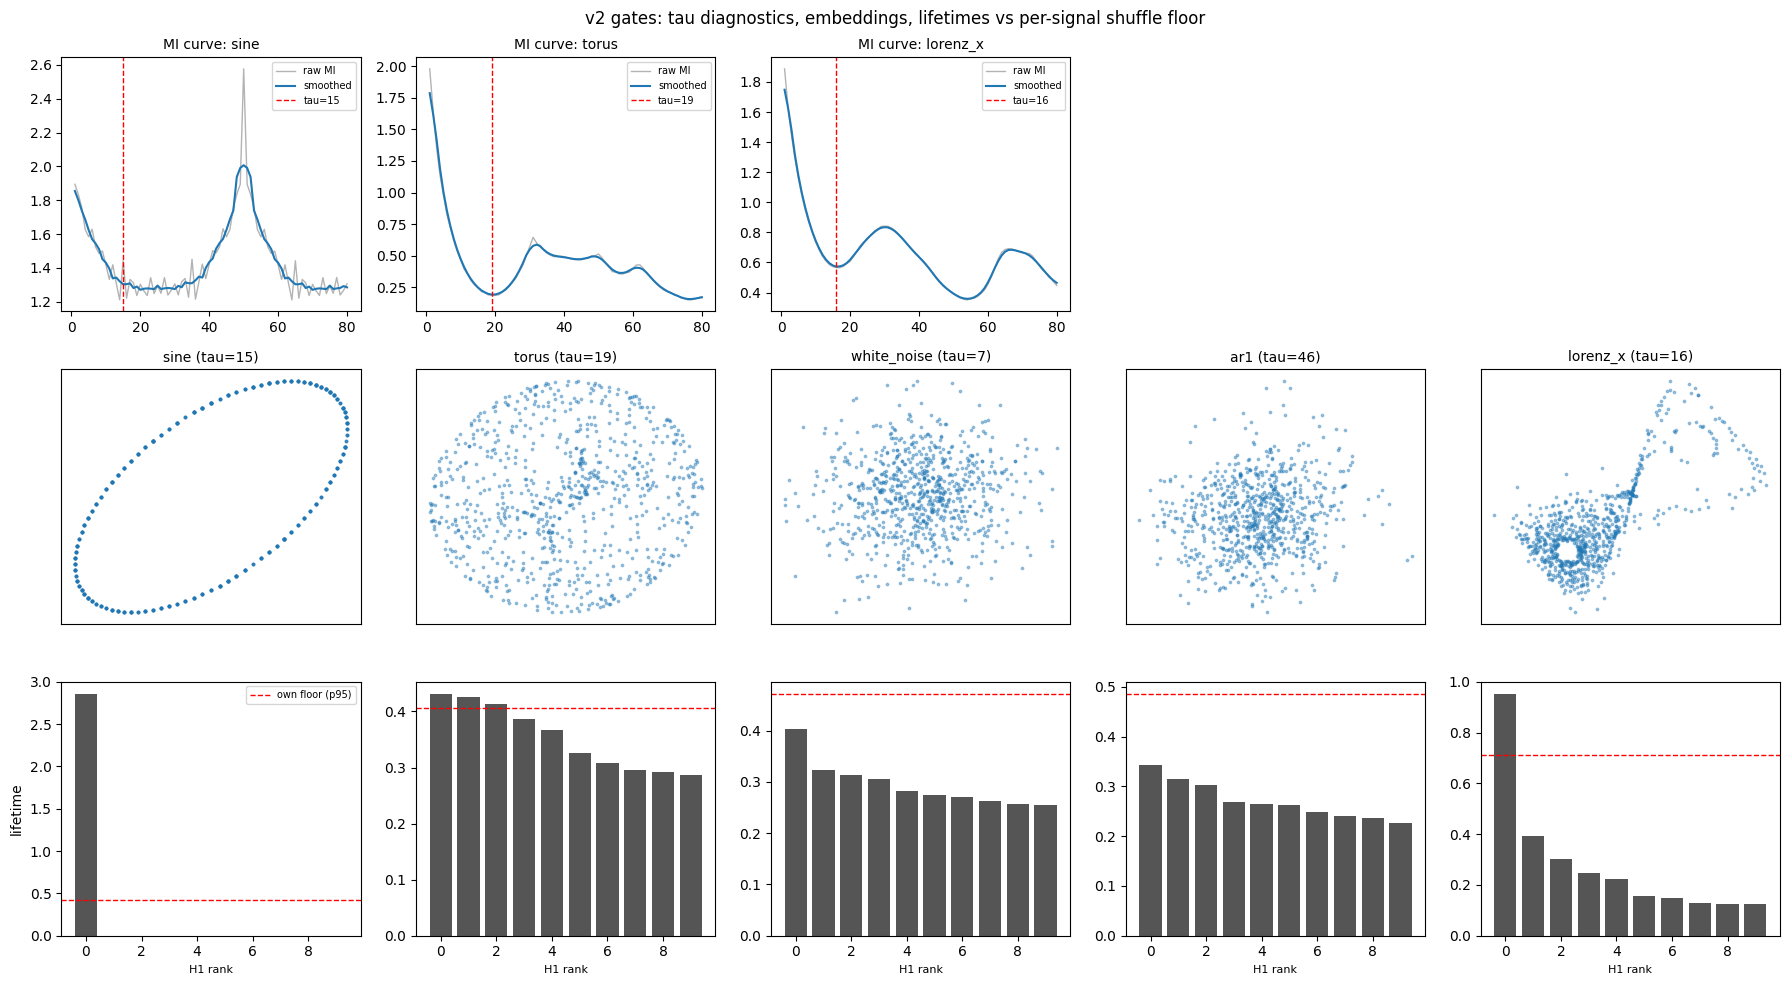

Saved tda_gate_visual_v2.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for j, k in enumerate(['sine', 'torus', 'lorenz_x']):
    r = results[k]
    ax = axes[0, j]
    ax.plot(range(1, len(r['mi_raw']) + 1), r['mi_raw'], color='0.7', lw=1, label='raw MI')
    ax.plot(range(1, len(r['mi_smooth']) + 1), r['mi_smooth'], color='tab:blue', lw=1.5, label='smoothed')
    ax.axvline(r['tau'], color='r', ls='--', lw=1, label=f"tau={r['tau']}")
    ax.set_title(f"MI curve: {k}", fontsize=10); ax.legend(fontsize=7)
axes[0, 3].axis('off'); axes[0, 4].axis('off')

show = ['sine', 'torus', 'white_noise', 'ar1', 'lorenz_x']
for j, k in enumerate(show):
    r = results[k]
    ax = axes[1, j]
    ax.scatter(r['cloud'][:, 0], r['cloud'][:, 1], s=3, alpha=0.4)
    ax.set_title(f"{k} (tau={r['tau']})", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax = axes[2, j]
    lt = r['lifetimes'][:10]
    ax.bar(range(len(lt)), lt, color='#555')
    ax.axhline(floors[k], color='r', ls='--', lw=1, label='own floor (p95)')
    ax.set_xlabel('H1 rank', fontsize=8)
    if j == 0:
        ax.set_ylabel('lifetime'); ax.legend(fontsize=7)

plt.suptitle('v2 gates: tau diagnostics, embeddings, lifetimes vs per-signal shuffle floor')
plt.tight_layout()
plt.savefig('tda_gate_visual_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tda_gate_visual_v2.png")

## If gates pass

Mirror into the real-data notebook before running real Weather/ETTh:
1. Replace `mutual_information_tau` calls with `robust_tau` (same
   parameters as here).
2. Add per-channel shuffle floors (M=10, p95) and report, per channel:
   top1, top1/own_floor, top1/top2, n_features above own floor,
   total_pers — not max_pers alone.
3. Keep d=3, n_points=800, N_POINTS_TIMESERIES=3000 unchanged so gate
   validation transfers.

If C_lorenz lands in 2.0-3.0 again: report as a documented near-miss.
The decision is then to strengthen the measurement (n_points=1200 in
BOTH notebooks, rerun gates), never to lower the pre-registered bar.